`Note: Monthly returns`

# Imports and Data Loading
First, we load the required packages and fetch the true target data (`y_true` and `dates`) for the KR dataset from 1971-08-31 to 2025-06-30.

In [27]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

import utils.base_utils as bu
import utils.window_utils as wu

# Configure target series configuration matched to the orchestrator runs
start_date = '1971-08-31'
end_date = '2025-06-30'
OOS_start_idx = pd.Timestamp('1990-01-31')

# For KR yields (annual maturities, holding period = 12 months)
maturities = [str(i) for i in range(12, 121) if i % 12 == 0] 
yields = bu.get_yields(type='kr', start=start_date, end=end_date, maturities=maturities) # type can be kr, lw, gsw
xr = bu.get_excess_returns(yields, horizon=12).dropna() # horizon=12 means holding for 12 months

monthly_yields = bu.get_yields(type='kr', start=start_date, end=end_date, maturities=[str(i) for i in range(1, 121)]) # needed for monthly holding period excess returns. Not available for gsw
monthly_xr = bu.get_excess_returns(monthly_yields, horizon=1).dropna() # calculate monthly excess returns for robustness
monthly_xr = monthly_xr.loc[monthly_xr.index <= xr.index[-1]]

# Standard selected 6 maturities modeled in orchestrator runs
target_maturities = ['24', '36', '48', '60', '84', '120']
y_true = monthly_xr[target_maturities].values
dates = monthly_xr.index

print(f"y_true shape: {y_true.shape}")
print(f"Dates range: {dates[0].strftime('%Y-%m-%d')} to {dates[-1].strftime('%Y-%m-%d')}")

recession_indicator_path = os.path.join(root_dir, 'data', 'USREC.csv')
recession_indicators = pd.read_csv(recession_indicator_path, index_col=0, parse_dates=True)

y_true shape: (635, 6)
Dates range: 1971-08-31 to 2024-06-30


## Load Orchestrator Runs

Here we pull the `val_loss` (or `trailing_oos`) ensemble forecasts for the two multi-output ANN specifications.

In [23]:
import json

# Paths to the specific orchestrated model runs
forward_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'run_1971_2025_kr_MONTHLY_revised', 'fwd_ann_3&3_100runs_top10', '20260513_102346')
# macro_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'run_1971_2025_kr_MONTHLY_realtime', 'macro_fwd_ann_fwd3&3&3_macro32_100runs_top10', '20260513_184216') # realtime
# group_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'run_1971_2025_kr_MONTHLY_realtime', 'group_ens_ann_fwd3&3_grp1_100runs_top10', '20260513_235701') # realtime
macro_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'run_1971_2025_kr_MONTHLY_revised', 'macro_fwd_ann_fwd3&3&3_macro32_100runs_top10', '20260513_114155') # revised
group_dir = os.path.join(root_dir, 'artifacts', 'orchestrator_runs', 'run_1971_2025_kr_MONTHLY_revised', 'group_ens_ann_fwd3&3_grp1_100runs_top10', '20260513_135710') # revised

# Using the val_loss criteria ensembles
forward_ens = np.load(os.path.join(forward_dir, 'ensemble_forecast_val_loss.npy'))
macro_ens = np.load(os.path.join(macro_dir, 'ensemble_forecast_val_loss.npy'))
group_ens = np.load(os.path.join(group_dir, 'ensemble_forecast_val_loss.npy'))

print(f"Forward ensemble shape: {forward_ens.shape}")
print(f"Macro ensemble shape: {macro_ens.shape}")
print(f"Group ensemble shape: {group_ens.shape}")

Forward ensemble shape: (635, 6)
Macro ensemble shape: (635, 6)
Group ensemble shape: (635, 6)


# r2oos up to 2018:

In [ ]:
# Load trailing OOS ensembles
forward_ens_tr = np.load(os.path.join(forward_dir, 'ensemble_forecast_trailing_oos.npy'))
macro_ens_tr = np.load(os.path.join(macro_dir, 'ensemble_forecast_trailing_oos.npy'))
group_ens_tr = np.load(os.path.join(group_dir, 'ensemble_forecast_trailing_oos.npy'))

# Load seed-level forecasts and selected top-k indices for group ensemble winsorization
group_forecasts_all = np.load(os.path.join(group_dir, 'forecasts_arr.npy'))
group_topk_vl = np.load(os.path.join(group_dir, 'topk_indices_val_loss.npy'))
group_topk_tr = np.load(os.path.join(group_dir, 'topk_indices_trailing_oos.npy'))

def build_winsorized_topk_ensemble(
    forecasts_arr,
    topk_indices,
    q_low=0.10,
    q_high=0.90,
    n_mad=3.0,
    min_k=3,
):
    """
    Rebuild ensemble from selected top-k seed forecasts, winsorizing per (time, maturity).
    Trimming uses a robust cap: intersection of quantile caps and median-MAD caps.
    """
    T, _, M = forecasts_arr.shape
    ens = np.full((T, M), np.nan)

    for t in range(T):
        for m in range(M):
            selected = topk_indices[t, m, :]
            selected = selected[selected >= 0]
            if selected.size == 0:
                continue

            vals = forecasts_arr[t, selected, m].astype(float)
            vals = vals[np.isfinite(vals)]
            if vals.size == 0:
                continue

            if vals.size >= min_k:
                # Quantile caps
                lo_q = np.quantile(vals, q_low)
                hi_q = np.quantile(vals, q_high)

                # Robust MAD caps
                med = np.median(vals)
                mad = np.median(np.abs(vals - med))
                if mad > 0:
                    robust_sigma = 1.4826 * mad
                    lo_mad = med - n_mad * robust_sigma
                    hi_mad = med + n_mad * robust_sigma

                    # Use the tighter overlap of both cap types
                    lo = max(lo_q, lo_mad)
                    hi = min(hi_q, hi_mad)
                    if lo > hi:
                        lo, hi = lo_q, hi_q
                else:
                    lo, hi = lo_q, hi_q

                vals = np.clip(vals, lo, hi)

            ens[t, m] = np.nanmean(vals)

    return ens

# Winsorized group ensembles (same top-k membership, robust aggregation)
group_ens_vl_win = build_winsorized_topk_ensemble(
    group_forecasts_all, group_topk_vl, q_low=0.10, q_high=0.90, n_mad=3.0
    )
group_ens_tr_win = build_winsorized_topk_ensemble(
    group_forecasts_all, group_topk_tr, q_low=0.10, q_high=0.90, n_mad=3.0
    )

def get_period_performance(mask, gap):
    # Pass full y_true to preserve the historical mean benchmark length,
    # but apply NaNs to the forecast vectors outside the evaluation mask
    y_t = y_true.copy()
    
    def mask_forecast(forecast):
        f = forecast.copy()
        f[~mask] = np.nan
        return f
    
    # Val loss
    fwd_vl = mask_forecast(forward_ens)
    mac_vl = mask_forecast(macro_ens)
    grp_vl = mask_forecast(group_ens)
    
    # Trailing OOS
    fwd_tr = mask_forecast(forward_ens_tr)
    mac_tr = mask_forecast(macro_ens_tr)
    grp_tr = mask_forecast(group_ens_tr)
    
    def score(fcst_series, i):
        r2 = wu.oos_r2(y_t[:, i], fcst_series, gap=gap)
        try:
            pval = bu.RSZ_Signif(y_t[:, i], fcst_series, gap=gap)
            stars = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else ""
            pval_str = f" ({pval:.3f})"
        except Exception:
            stars = ""
            pval_str = ""
        return f"{r2:.4f}{stars}{pval_str}"
        
    res = []
    for i, mat in enumerate(target_maturities):
        res.append({
            'Maturity': mat,
            'Fwd (Val Loss)': score(fwd_vl[:, i], i),
            'Fwd (Trailing)': score(fwd_tr[:, i], i),
            'Macro (Val Loss)': score(mac_vl[:, i], i),
            'Macro (Trailing)': score(mac_tr[:, i], i),
            'Group (Val Loss)': score(grp_vl[:, i], i),
            'Group (Trailing)': score(grp_tr[:, i], i),
        })
    return pd.DataFrame(res)

def get_group_winsorized_performance(mask, gap):
    # Separate robustness table for winsorized group ensemble
    y_t = y_true.copy()
    
    def mask_forecast(forecast):
        f = forecast.copy()
        f[~mask] = np.nan
        return f
    
    grp_vl_win = mask_forecast(group_ens_vl_win)
    grp_tr_win = mask_forecast(group_ens_tr_win)
    
    def score(fcst_series, i):
        r2 = wu.oos_r2(y_t[:, i], fcst_series, gap=gap)
        try:
            pval = bu.RSZ_Signif(y_t[:, i], fcst_series, gap=gap)
            stars = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else ""
            pval_str = f" ({pval:.3f})"
        except Exception:
            stars = ""
            pval_str = ""
        return f"{r2:.4f}{stars}{pval_str}"
    
    res = []
    for i, mat in enumerate(target_maturities):
        res.append({
            'Maturity': mat,
            'Group (Val Loss, Winsorized)': score(grp_vl_win[:, i], i),
            'Group (Trailing, Winsorized)': score(grp_tr_win[:, i], i),
        })
    return pd.DataFrame(res)

mask_2018 = (dates >= pd.Timestamp('1990-01-31')) & (dates <= pd.Timestamp('2018-12-31'))
mask_2025 = (dates >= pd.Timestamp('1990-01-31')) & (dates <= pd.Timestamp('2025-12-31'))
mask_2019_2025 = (dates >= pd.Timestamp('2019-01-31')) & (dates <= pd.Timestamp('2025-12-31'))

df_2018 = get_period_performance(mask_2018, gap=0)
df_2025 = get_period_performance(mask_2025, gap=0)
df_2019_2025 = get_period_performance(mask_2019_2025, gap=0)

# Robustness table for thesis main-body text
df_2018_win = get_group_winsorized_performance(mask_2018, gap=0)
df_2025_win = get_group_winsorized_performance(mask_2025, gap=0)
df_2019_2025_win = get_group_winsorized_performance(mask_2019_2025, gap=0)

from IPython.display import display

print("Performance (R2 OOS) 1990-01-31 to 2018-12-31:")
display(df_2018)

print("\nPerformance (R2 OOS) 1990-01-31 to 2025-06-30:")
display(df_2025)

print("\nPerformance (R2 OOS) 2019-01-31 to 2025-06-30:")
display(df_2019_2025)

print("\nGroup Ensemble Robustness (Winsorized Top-k) 1990-01-31 to 2018-12-31:")
display(df_2018_win)

print("\nGroup Ensemble Robustness (Winsorized Top-k) 1990-01-31 to 2025-06-30:")
display(df_2025_win)

print("\nGroup Ensemble Robustness (Winsorized Top-k) 2019-01-31 to 2025-06-30:")
display(df_2019_2025_win)

print("\nNote: Main table keeps raw results. Winsorized table trims top-k seed outliers using quantile + MAD caps per date/maturity.")
print("Note: Significance: *** p<0.01, ** p<0.05, * p<0.10 (Clark-West / RSZ test)")

Performance (R2 OOS) 1990-01-31 to 2018-12-31:


,Maturity,Fwd (Val Loss),Fwd (Trailing),Macro (Val Loss),Macro (Trailing),Group (Val Loss),Group (Trailing)
0,24,-0.0380 (0.692),-0.0200 (0.167),-0.1483** (0.030),-0.0453 (0.175),0.0016*** (0.001),-0.0246*** (0.007)
1,36,-0.0345 (0.777),-0.0174 (0.161),-0.1932** (0.031),-0.0184* (0.057),0.0303*** (0.001),-0.0381 (0.109)
2,48,-0.0126 (0.384),-0.0147 (0.191),-0.2242** (0.033),-0.0147 (0.131),-0.0023*** (0.003),0.0020* (0.056)
3,60,-0.0126 (0.502),-0.0113 (0.215),-0.0865** (0.038),0.0028** (0.047),-0.0116*** (0.002),0.0256** (0.015)
4,84,-0.0120 (0.568),0.0051* (0.055),-0.1397* (0.096),-0.0004* (0.076),0.0013** (0.026),-0.0309 (0.585)
5,120,-0.0086 (0.539),0.0012* (0.082),-0.1287* (0.074),-0.0007** (0.029),-0.0156** (0.032),-0.0023 (0.133)



Performance (R2 OOS) 1990-01-31 to 2025-06-30:


,Maturity,Fwd (Val Loss),Fwd (Trailing),Macro (Val Loss),Macro (Trailing),Group (Val Loss),Group (Trailing)
0,24,-0.0169 (0.387),0.0003* (0.057),-0.1213** (0.025),-0.0337 (0.126),-0.0142*** (0.000),-0.0167*** (0.003)
1,36,-0.0212 (0.543),-0.0016* (0.063),-0.1598** (0.028),-0.0140** (0.037),0.0218*** (0.000),-0.0272** (0.048)
2,48,-0.0063 (0.264),-0.0077 (0.117),-0.1889** (0.033),-0.0120 (0.121),-0.0230*** (0.006),0.0021** (0.045)
3,60,-0.0078 (0.383),-0.0048 (0.131),-0.0830** (0.042),-0.0007** (0.049),-0.0173*** (0.001),0.0140** (0.017)
4,84,-0.0091 (0.495),0.0065** (0.035),-0.1252 (0.114),-0.0030* (0.076),-0.0132** (0.046),-0.0280 (0.607)
5,120,-0.0080 (0.522),-0.0014* (0.088),-0.1126* (0.090),-0.0039** (0.045),-0.0269* (0.056),-0.0122 (0.220)



Performance (R2 OOS) 2019-01-31 to 2025-06-30:


...


Group Ensemble Robustness (Winsorized Top-k) 1990-01-31 to 2025-06-30:


,Maturity,"Group (Val Loss, Winsorized)","Group (Trailing, Winsorized)"
0,24,0.0050*** (0.001),-0.0109*** (0.005)
1,36,0.0139*** (0.001),-0.0098** (0.038)
2,48,-0.0093** (0.012),0.0111** (0.025)
3,60,0.0159*** (0.001),0.0135** (0.016)
4,84,-0.0110* (0.056),-0.0168 (0.589)
5,120,-0.0240 (0.103),-0.0139 (0.376)



Group Ensemble Robustness (Winsorized Top-k) 2019-01-31 to 2025-06-30:


,Maturity,"Group (Val Loss, Winsorized)","Group (Trailing, Winsorized)"
0,24,-0.0457* (0.093),0.0412* (0.087)
1,36,-0.0049 (0.152),0.0094* (0.081)
2,48,-0.0931 (0.779),0.0079 (0.173)
3,60,-0.0190 (0.146),-0.0234 (0.311)
4,84,-0.0617 (0.756),-0.0220 (0.725)
5,120,-0.0790 (0.724),-0.0389 (0.704)



Note: Main table keeps raw results. Winsorized table trims top-k seed outliers using quantile + MAD caps per date/maturity.
Note: Significance: *** p<0.01, ** p<0.05, * p<0.10 (Clark-West / RSZ test)


## CSSED Plots

Next, we generate the Cumulative Sum of Squared Error Differences (CSSED) plots relative to the Historical Mean benchmark. We add a secondary line starting in 2019-01-31 to highlight the recent Out-of-Sample performance.

A positive slope implies the model is outperforming the benchmark, and a negative slope implies underperformance.

Plotting for Maturity: 48 months


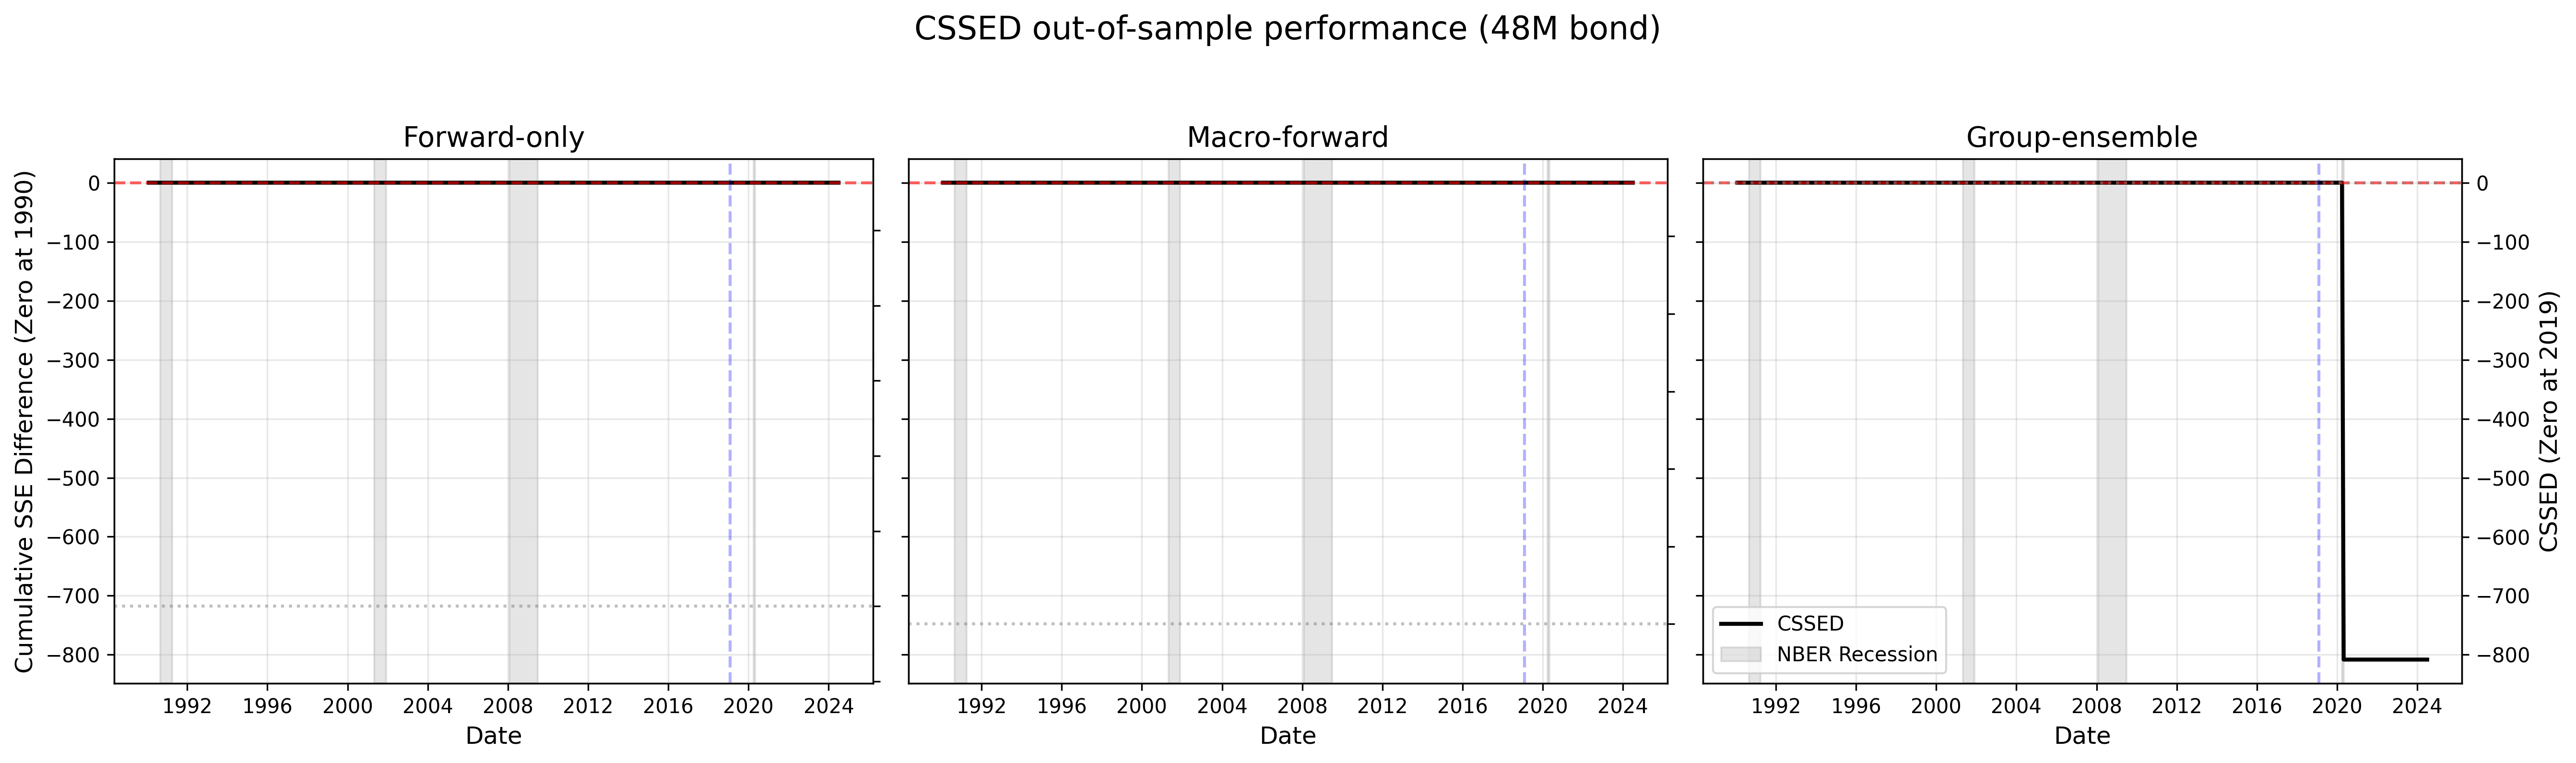

In [15]:
# Set the secondary start for the CSSED plot
secondary_start = pd.Timestamp('2019-01-31')
gap = 11

# Let's plot for 10-year maturity (index -1 corresponds to '120')
mat_idx = -4
print(f"Plotting for Maturity: {target_maturities[mat_idx]} months")

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, dpi=300)
names = ['Forward-only', 'Macro-forward', 'Group-ensemble']
ensembles = [forward_ens, macro_ens, group_ens]

for ax, name, ens in zip(axes, names, ensembles):
    # Align data and filter for OOS period
    df = pd.DataFrame({
        'realized': y_true[:, mat_idx],
        'forecast': ens[:, mat_idx]
    }, index=dates)
    
    oos_df = df.loc[OOS_start_idx:].copy()
    
    # Generate Historical Mean Benchmark (Expanding Window)
    full_series = pd.Series(y_true[:, mat_idx], index=dates)
    oos_df['hist_mean_bench'] = [full_series.loc[:d].iloc[:-1].mean() for d in oos_df.index]
    
    oos_df['error_model'] = (oos_df['realized'] - oos_df['forecast'])**2
    oos_df['error_bench'] = (oos_df['realized'] - oos_df['hist_mean_bench'])**2
    oos_df['cssed'] = (oos_df['error_bench'] - oos_df['error_model']).cumsum()
    
    ax.plot(oos_df.index, oos_df['cssed'], color='black', linewidth=2, label='CSSED')
    ax.axhline(0, color='red', linestyle='--', alpha=0.6)
    
    # Add recession shading
    oos_rec = recession_indicators.reindex(oos_df.index, method='ffill').fillna(0)
    ax.fill_between(oos_df.index, 0, 1, where=(oos_rec['USREC'] == 1), 
                    color='gray', alpha=0.2, transform=ax.get_xaxis_transform(), label='NBER Recession')
    
    ax.set_title(name, fontsize=14)
    ax.set_xlabel('Date', fontsize=12)
    ax.grid(alpha=0.3)
    
    if secondary_start and secondary_start in oos_df.index:
        val_at_secondary = oos_df.loc[secondary_start, 'cssed']
        ax2 = ax.twinx()
        y1_min, y1_max = ax.get_ylim()
        ax2.set_ylim(y1_min - val_at_secondary, y1_max - val_at_secondary)
        ax2.axhline(0, color='gray', linestyle=':', alpha=0.5)
        ax.axvline(secondary_start, color='blue', linestyle='--', alpha=0.3)
        
        # Only add the secondary y-label on the rightmost plot
        if ax == axes[-1]:
            ax2.set_ylabel(f'CSSED (Zero at {secondary_start.year})', fontsize=12)
        else:
            ax2.set_yticklabels([]) # Hide tick labels so it doesn't clutter the middle of the grid
            
    # Add primary y-label only on the leftmost plot
    if ax == axes[0]:
        ax.set_ylabel(f'Cumulative SSE Difference (Zero at {OOS_start_idx.year})', fontsize=12)

# Custom legend on the last ax
custom_lines = [
    Line2D([0], [0], color='black', lw=2),
    mpatches.Patch(color='gray', alpha=0.2)
]
axes[-1].legend(custom_lines, ['CSSED', 'NBER Recession'], loc='best', prop={'size': 10})

fig.suptitle(f'CSSED out-of-sample performance ({target_maturities[mat_idx]}M bond)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## Seed Stability and Disperion 

For a high-quality finance publication, demonstrating the robustness of machine learning models to the random initialization weight (the "seed") is paramount. 
We propose two foundational figures for the paper:

1. **Ensemble Value Add (R2 Distribution Boxplot):** Demonstrates whether the top-10 val loss ensemble merely captures the average performance of the model class, or actively selects superior weights preventing massive downside risk.
2. **Forecast Uncertainty (Spaghetti Plot):** Demonstrates how widely the underlying model predictions diverge during high volatility periods (like the 2020 drop and subsequent recovery).

First, we load the raw individual seed forecasts for all 100 models.

In [10]:
# Load the full (100 seeds) forecast arrays
macro_forecasts_all = np.load(os.path.join(macro_dir, 'forecasts_arr.npy'))
group_forecasts_all = np.load(os.path.join(group_dir, 'forecasts_arr.npy'))

print(f"Shape of macro_forecasts_all: {macro_forecasts_all.shape} (Time, Seeds, Maturities)")

Shape of macro_forecasts_all: (635, 100, 6) (Time, Seeds, Maturities)


## Seed instability visualization

Here we generate the finalized 1x3 grid plots comparing the Forward-only, Macro-Forward, and Group-Ensemble models side-by-side for the three seed instability arguments.

In [11]:
# Prepare data dictionaries for easy 1x3 iteration
model_dirs = {
    'Forward-only': forward_dir,
    'Macro-forward': macro_dir,
    'Group-ensemble': group_dir
}

forecasts_dict = {}
topk_dict = {}
ens_dict = {
    'Forward-only': forward_ens,
    'Macro-forward': macro_ens,
    'Group-ensemble': group_ens
}

for name, mdir in model_dirs.items():
    forecasts_dict[name] = np.load(os.path.join(mdir, 'forecasts_arr.npy'))
    topk_dict[name] = np.load(os.path.join(mdir, 'topk_indices_val_loss.npy'))

# Reconstruct loss_dates and start_plot_idx for the downstream plots
n_time = forecasts_dict['Group-ensemble'].shape[0]
loss_dates = dates[-n_time:]
start_plot_idx = np.where(loss_dates >= pd.Timestamp('2000-01-31'))[0][0]

/tmp/ipykernel_3425924/16693128.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(target_maturities)
/tmp/ipykernel_3425924/16693128.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(target_maturities)
/tmp/ipykernel_3425924/16693128.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(target_maturities)


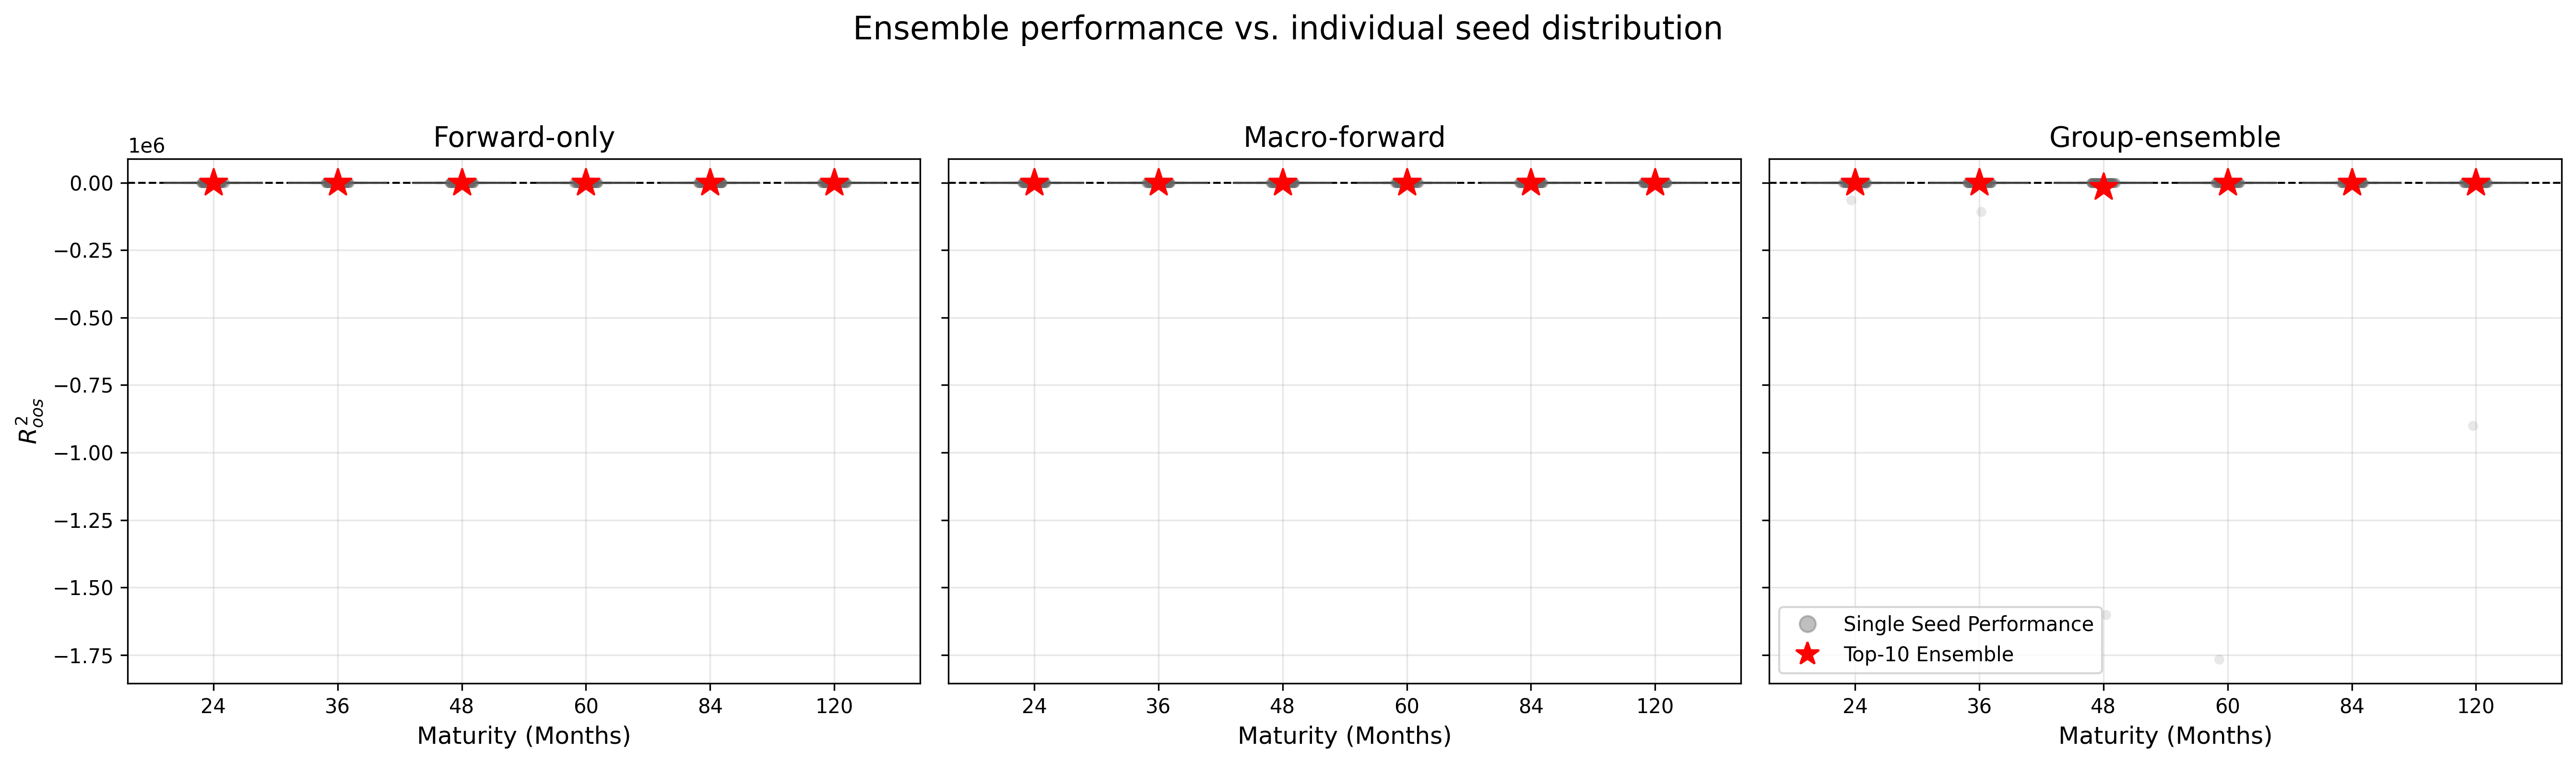

In [12]:
# 1. Ensemble Value Add (Boxplots)
def compute_all_seeds_r2(y_true_full, forecasts_all, gap=11):
    """Calculate Full-Sample OOS R2 for individual seeds across all maturities."""
    n_seeds = forecasts_all.shape[1]
    n_maturities = forecasts_all.shape[2]
    
    all_r2 = np.zeros((n_seeds, n_maturities))
    for s in range(n_seeds):
        for m in range(n_maturities):
            r2 = wu.oos_r2(y_true_full[:, m], forecasts_all[:, s, m], benchmark='hist_mean', gap=gap)
            all_r2[s, m] = r2
    return all_r2

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, dpi=300)

for ax, (name, f_all) in zip(axes, forecasts_dict.items()):
    seeds_r2 = compute_all_seeds_r2(y_true, f_all, gap=11)
    sns.boxplot(data=seeds_r2, ax=ax, color='lightgray', showfliers=False)
    sns.stripplot(data=seeds_r2, ax=ax, alpha=0.15, jitter=True, color='dimgray')
    
    # Overlay ensemble performance
    ens_r2s = [wu.oos_r2(y_true[:, m], ens_dict[name][:, m], benchmark='hist_mean', gap=11) for m in range(len(target_maturities))]
    ax.scatter(range(len(target_maturities)), ens_r2s, color='red', marker='*', s=200, zorder=5)
    
    ax.set_title(name, fontsize=14)
    ax.set_xticklabels(target_maturities)
    ax.set_xlabel('Maturity (Months)', fontsize=12)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('$R^2_{oos}$', fontsize=12)

# Custom legend on the last ax
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='gray', marker='o', linestyle='None', alpha=0.5, markersize=8),
    Line2D([0], [0], color='red', marker='*', linestyle='None', markersize=12)
]
axes[-1].legend(custom_lines, ['Single Seed Performance', 'Top-10 Ensemble'], loc='lower left', prop={'size': 10})

fig.suptitle('Ensemble performance vs. individual seed distribution', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

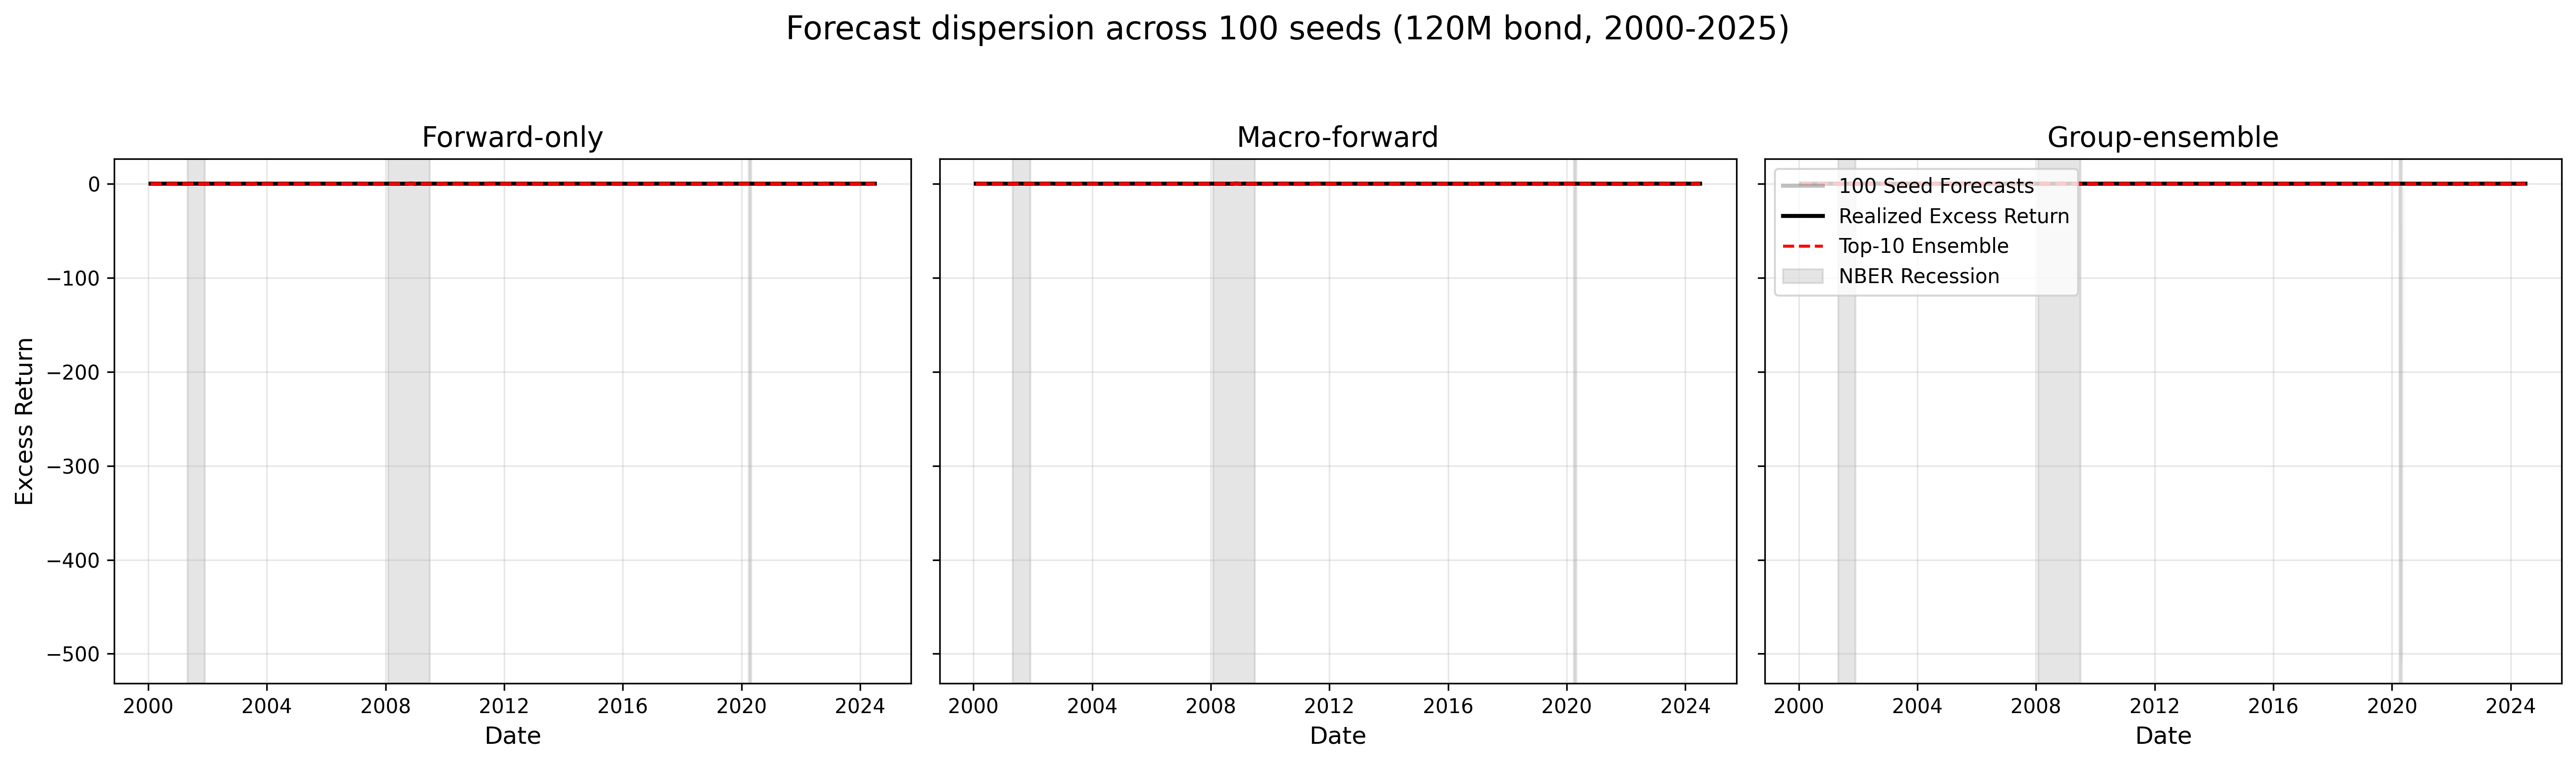

In [13]:
# 2. Forecast Dispersion (Spaghetti Plot)
mat_idx = -1 # 120M
time_subset = loss_dates[start_plot_idx:]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, dpi=300)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

for ax, (name, f_all) in zip(axes, forecasts_dict.items()):
    # Get the time slice starting from 2000-01-31
    # Find the corresponding index in the full dates array to match y_true
    full_date_idx = np.where(dates >= pd.Timestamp('2000-01-31'))[0][0]
    seeds_subset = f_all[full_date_idx:, :, mat_idx]
    
    ax.plot(time_subset, seeds_subset, color='gray', alpha=0.05) 
    ax.plot(time_subset, y_true[full_date_idx:, mat_idx], color='black', linewidth=2)
    ax.plot(time_subset, ens_dict[name][full_date_idx:, mat_idx], color='red', linewidth=1.5, linestyle='--')
    
    # Add recession shading
    rec_subset = recession_indicators.reindex(time_subset, method='ffill').fillna(0)
    ax.fill_between(time_subset, 0, 1, where=(rec_subset['USREC'] == 1), 
                    color='gray', alpha=0.2, transform=ax.get_xaxis_transform())
    
    ax.set_title(name, fontsize=14)
    ax.grid(alpha=0.3)
    ax.set_xlabel('Date', fontsize=12)

axes[0].set_ylabel('Excess Return', fontsize=12)

custom_lines = [
    Line2D([0], [0], color='gray', alpha=0.5, lw=2),
    Line2D([0], [0], color='black', lw=2),
    Line2D([0], [0], color='red', lw=1.5, linestyle='--'),
    mpatches.Patch(color='gray', alpha=0.2)
]
axes[-1].legend(custom_lines, ['100 Seed Forecasts', 'Realized Excess Return', 'Top-10 Ensemble', 'NBER Recession'], loc='upper left', prop={'size': 10})

fig.suptitle(f'Forecast dispersion across 100 seeds ({target_maturities[mat_idx]}M bond, 2000-2025)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

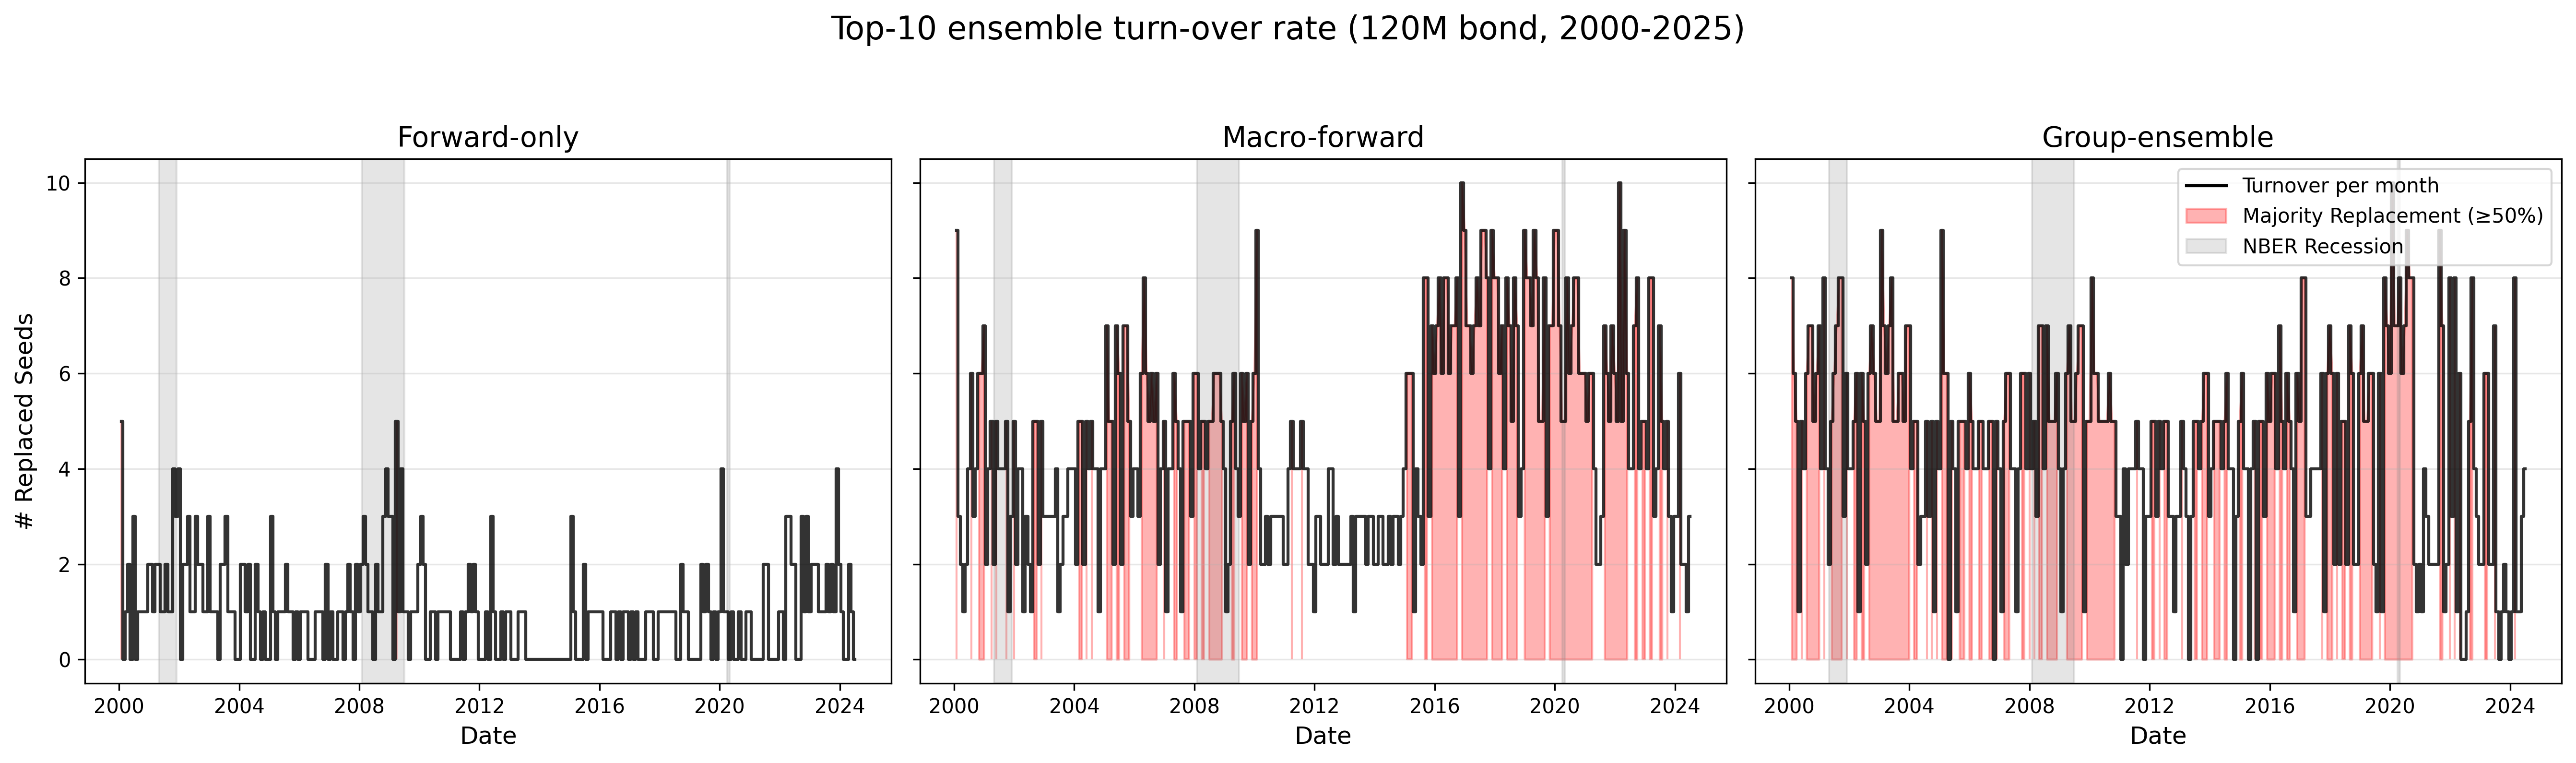

In [14]:
# 3. Ensemble Turnover / Churn Rate (1x3 Grid)
mat_idx = -1
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, dpi=300)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

for ax, (name, t_idx) in zip(axes, topk_dict.items()):
    n_time = t_idx.shape[0]
    turnover = np.zeros(n_time)
    
    for t in range(1, n_time):
        prev_topk = set(t_idx[t-1, mat_idx, :])
        curr_topk = set(t_idx[t, mat_idx, :])
        turnover[t] = len(curr_topk - prev_topk)
        
    time_subset = loss_dates[start_plot_idx:]
    ax.plot(time_subset, turnover[start_plot_idx:], color='black', drawstyle='steps-mid', alpha=0.8)
    
    ax.set_title(name, fontsize=14)
    ax.set_xlabel('Date', fontsize=12)
    
    # Shade periods of high instability
    high_turnover_mask = turnover[start_plot_idx:] >= 5
    ax.fill_between(time_subset, 0, turnover[start_plot_idx:], where=high_turnover_mask, color='red', alpha=0.3)
    
    # Add recession shading
    rec_subset = recession_indicators.reindex(time_subset, method='ffill').fillna(0)
    ax.fill_between(time_subset, 0, 1, where=(rec_subset['USREC'] == 1), 
                    color='gray', alpha=0.2, transform=ax.get_xaxis_transform())
    
    ax.set_yticks(np.arange(0, 11, 2))
    ax.grid(alpha=0.3, axis='y')

axes[0].set_ylabel('# Replaced Seeds', fontsize=12)

# Custom legend on the last ax
custom_patches = [
    Line2D([0], [0], color='black', lw=1.5, drawstyle='steps-mid'),
    mpatches.Patch(color='red', alpha=0.3),
    mpatches.Patch(color='gray', alpha=0.2)
]
axes[-1].legend(custom_patches, ['Turnover per month', 'Majority Replacement (≥50%)', 'NBER Recession'], loc='upper right', prop={'size': 10})

fig.suptitle(f'Top-10 ensemble turn-over rate ({target_maturities[mat_idx]}M bond, 2000-2025)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()